In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

os.chdir("../src")
os.getcwd()

from simulator.gca import Maxflow2GCA, VesselsGCA

%load_ext autoreload
%autoreload 2

/home/flyingleafe/Job/Clique/simple-eigentrust/python/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def graph_node_attrs(G, *attrs):
    n = G.number_of_nodes()
    attr_arrays = {}
    for attr in attrs:
        attr_arrays[attr] = np.zeros(n)

    for node, dd in G.nodes(data=True):
        for attr in attrs:
            attr_arrays[attr][node] = getattr(dd["state"], attr)

    return attr_arrays

def graph_sequence_node_attrs(Gs, *attrs):
    dicts = [graph_node_attrs(G, *attrs) for G in Gs]
    return {
        k: np.vstack([d[k] for d in dicts])
        for k in dicts[0].keys()
    }


def graph_balances_and_credit_limits(G):
    vals = graph_node_attrs(G, 'balance', 'credit_limit')
    return vals['balance'], vals['credit_limit']

def sequence_balances_and_credit_limits(Gs):
    bss, lss = zip(*map(graph_balances_and_credit_limits, Gs))
    return np.vstack(bss), np.vstack(lss)


def plot_balances_and_credit_limits(balances, limits):
    assert len(balances) == len(limits)
    x = np.arange(len(balances))
    plt.bar(x, balances, label='Available balances')
    plt.bar(x, limits, bottom=balances, label='Credit limits')
    plt.legend()
    plt.show()

In [7]:
mini_graph = nx.DiGraph()

mini_graph.add_node(0)
mini_graph.add_node(1)

mini_graph.add_edge(0, 1, capacity=10, height=500)

init_balances = {0: 100000, 1: 1000}

gca = VesselsGCA(mini_graph, balance_distribution=init_balances)

print(mini_graph.in_edges[0, 1])
print(mini_graph.out_edges.get((1, 0)))

records = gca.run_simulation(100)


{'capacity': 10, 'height': 500, 'state': VesselEdgeState(capacity=10.0, flow=0.0, phantom_flow=0.0, height=500.0)}
None

                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 100, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (100, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 481.83it/s]


Execution Method: single_proc_exec


Flattening results:   1%|▎                                   | 1/101 [00:00<00:00, 328.63it/s]

Total execution time: 0.04s


In [8]:
phantom_balances = graph_node_attrs(

(array([[100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   1000.],
        [100000.,   

In [4]:
def create_simulation_maxflow2(graph):
    
    num_edges = graph.number_of_edges()
    capacities = list(np.random.randint(1, 10000, num_edges))
    balances = {node: np.random.randint(1, 100000) for node in graph.nodes}
    
    for edge in graph.edges:
        graph.edges[edge]["capacity"] = capacities.pop()
    
    gca = Maxflow2GCA(graph, balance_distribution=balances)
    records = gca.run_simulation(10)
    return records

In [5]:
# Create a Watts-Strogatz graph
n = 1000  # number of nodes
k = 10    # each node is connected to k nearest neighbors in ring topology
p = 0.1   # the probability of rewiring each edge

records = []

graph_1 = nx.barabasi_albert_graph(n, 2, seed=42)
records.append({
    "title": "barabasi_albert_graph",
    "graph": graph_1,
    "records": create_simulation_maxflow2(graph_1)
})


graph_2 = nx.watts_strogatz_graph(n, k, p, seed=42)
records.append({
    "title": "watts_strogatz_graph",
    "graph": graph_2,
    "records": create_simulation_maxflow2(graph_2)
})



                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 10, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (10, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████| 1/1 [00:00<00:00, 596.37it/s]

Execution Method: single_proc_exec


AttributeError: 'Graph' object has no attribute 'predecessors'

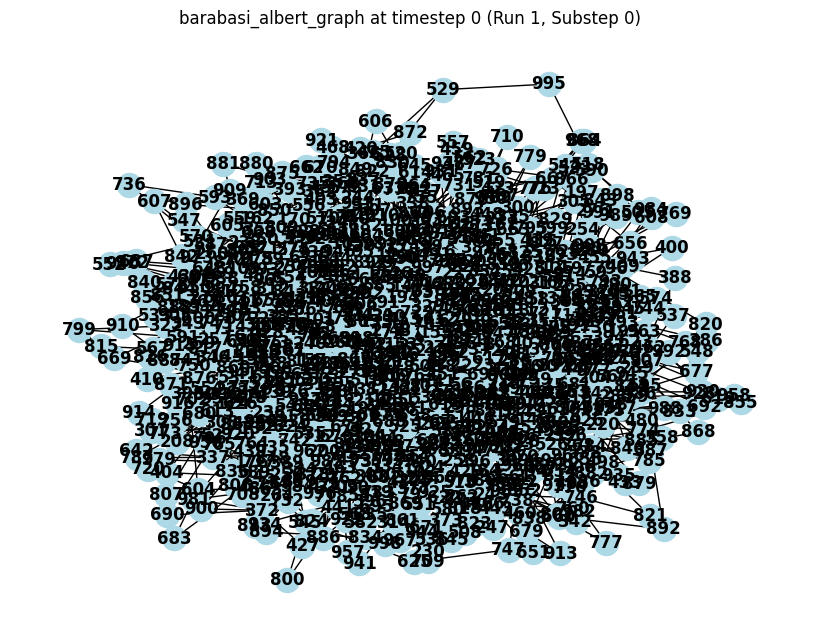

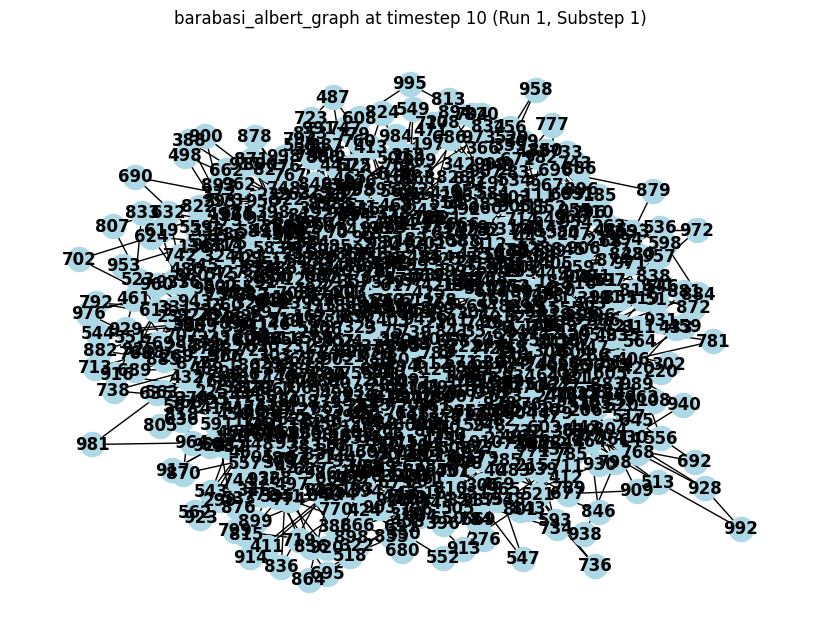

AttributeError: 'Series' object has no attribute 'is_directed'

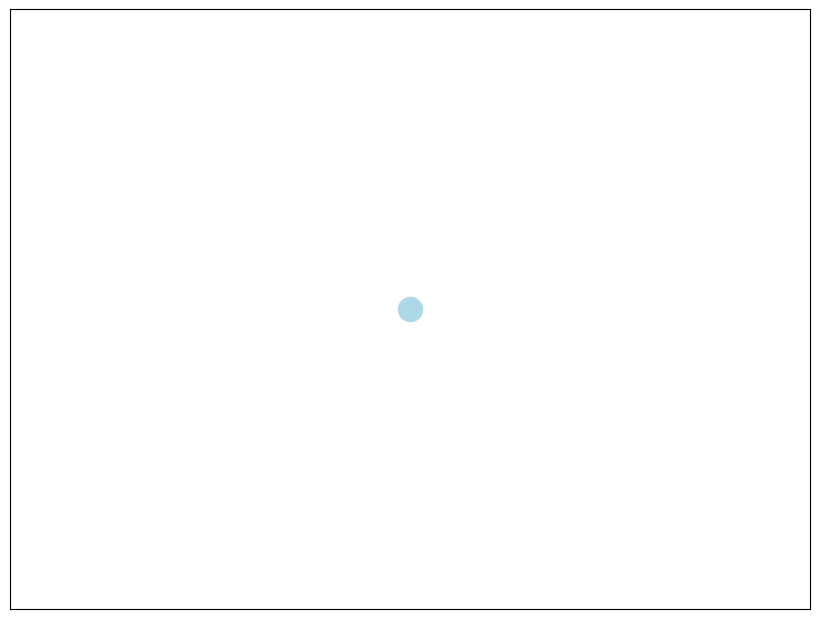

In [63]:

def plot_graph(title, record):
    graph = record['graph']
    plt.figure(figsize=(8, 6))  # Create a new figure for each graph
    nx.draw(graph, with_labels=True, node_color='lightblue', font_weight='bold')
    plt.title(f"{title} at timestep {record['timestep']} (Run {record['run']}, Substep {record['substep']})")
    plt.show()

# Plot each record
for i, record_state in enumerate(records):
    for steps in record_state['records']:
        plot_graph(record_state['title'], steps[0])
        plot_graph(record_state['title'], steps[-1])
    